# Desafío — Predicción del precio de vuelos
## Daniel Rojas López

Este notebook desarrolla las actividades 1 y 2 de la prueba. Los cálculos se ejecutan directamente sobre los archivos `business.xlsx` y `economy.xlsx`.

## 1. Problema de negocio y metodología

Una agencia de viajes en línea necesita entregar a sus clientes una estimación confiable del precio de un boleto aéreo antes de completar una reserva. El precio depende de factores operacionales y comerciales, tales como la clase del pasaje, aerolínea, ruta, fecha, horario, duración y número de escalas.

**Objetivo:** construir un modelo de regresión supervisada que prediga la variable objetivo `price`, expresada en la moneda original del dataset. Cada observación representa una oferta de vuelo para una fecha, ruta, aerolínea, horario y clase específicos.

**Metodología (CRISP-DM):**
1. Comprensión del negocio y de los datos.
2. Auditoría de calidad, limpieza e ingeniería de variables.
3. Análisis exploratorio y selección de variables.
4. Entrenamiento y ajuste de modelos de regresión.
5. Evaluación con MAE, RMSE y R², comparando contra un baseline que predice la mediana del precio.

Se unirán las dos bases y se conservará el origen de cada observación mediante `cabin_class` (`Business` o `Economy`). Esto permite que el modelo use la clase como predictor y evita mezclar tarifas de segmentos diferentes sin identificarlas.

In [2]:
# Actividad 1: se describirá el problema, la variable objetivo y la metodología que guiará el modelamiento.
# Librerías y configuración
from pathlib import Path
import re

import numpy as np
import pandas as pd
def display(obj):
    print(obj)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path('.')
BUSINESS_FILE = DATA_DIR / 'business.xlsx'
ECONOMY_FILE = DATA_DIR / 'economy.xlsx'


## 2. Carga y reporte de calidad de datos

Primero se cargan los dos archivos y se incorpora `cabin_class`. Luego se revisan dimensiones, tipos, nulos, duplicados, consistencia de la variable objetivo y formatos que requieren tratamiento.

In [3]:
# Actividad 2: se cargarán los archivos y se validarán dimensiones, nulos, duplicados y formatos de las variables.
# Carga de las fuentes y consolidación

business = pd.read_excel(BUSINESS_FILE).assign(cabin_class='Business')
economy = pd.read_excel(ECONOMY_FILE).assign(cabin_class='Economy')
flights_raw = pd.concat([business, economy], ignore_index=True)

print(f'Business: {business.shape[0]:,} filas y {business.shape[1] - 1} columnas originales')
print(f'Economy:  {economy.shape[0]:,} filas y {economy.shape[1] - 1} columnas originales')
print(f'Consolidado: {flights_raw.shape[0]:,} filas y {flights_raw.shape[1]} columnas')
display(flights_raw.head())
display(flights_raw.dtypes.rename('tipo').to_frame())


Business: 93,487 filas y 11 columnas originales
Economy:  206,774 filas y 11 columnas originales
Consolidado: 300,261 filas y 12 columnas
        date    airline ch_code  num_code  dep_time   from time_taken  \
0 2022-02-11  Air India      AI       868  18:00:00  Delhi    02h 00m   
1 2022-02-11  Air India      AI       624  19:00:00  Delhi    02h 15m   
2 2022-02-11  Air India      AI       531  20:00:00  Delhi    24h 45m   
3 2022-02-11  Air India      AI       839  21:25:00  Delhi    26h 30m   
4 2022-02-11  Air India      AI       544  17:15:00  Delhi    06h 40m   

                                                stop  arr_time      to  price  \
0                                           non-stop  20:00:00  Mumbai  25612   
1                                           non-stop  21:15:00  Mumbai  25612   
2  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...  20:45:00  Mumbai  42220   
3  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...  23:55:00  Mumbai  44450   
4  1-stop\n\t\t\t\

## 3. Genera un análisis exploratorio de los dataset entregados, un análisis univariado y bivariado. Prioriza los gráficos más importantes y entrega una conclusión a partir de estos.

In [4]:
# Actividad 3: se limpiarán los datos y se generarán gráficos univariados y bivariados para explorar el precio.
# Funciones auxiliares para la auditoría de calidad
def duration_to_minutes(value):
    """Convierte duraciones como '02h 15m' o '1.03h m' a minutos."""
    text = str(value).strip().replace('h m', 'h')
    match = re.fullmatch(r'(\d+)(?:[.](\d+))?h\s*(?:(\d+)m)?', text)
    if not match:
        return np.nan
    hours, malformed_minutes, minutes = match.groups()
    return int(hours) * 60 + int(minutes or malformed_minutes or 0)

def normalized_stop(value):
    """Elimina saltos de línea y detalle de escala; conserva 0, 1 o 2+ escalas."""
    text = re.sub(r'\s+', ' ', str(value)).strip()
    return re.sub(r' Via .*$', '', text)

def quality_report(df, dataset_name):
    price_numeric = pd.to_numeric(df['price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
    parsed_duration = df['time_taken'].map(duration_to_minutes)
    stop_clean = df['stop'].map(normalized_stop)
    return {
        'dataset': dataset_name,
        'filas': len(df),
        'columnas': len(df.columns) - int('cabin_class' in df.columns),
        'celdas_nulas': int(df.isna().sum().sum()),
        'duplicados_exactos': int(df.drop(columns='cabin_class', errors='ignore').duplicated().sum()),
        'precio_no_numerico': int(price_numeric.isna().sum()),
        'precio_no_positivo': int((price_numeric <= 0).sum()),
        'duracion_no_interpretable': int(parsed_duration.isna().sum()),
        'stop_con_formato_sucio': int((df['stop'].astype(str) != stop_clean).sum()),
        'origen_igual_destino': int((df['from'] == df['to']).sum()),
        'fecha_minima': df['date'].min().date(),
        'fecha_maxima': df['date'].max().date(),
    }


## 4. Realiza un análisis de correlaciones entre las diferentes variables existentes,identificando cuáles son las variables más importantes para la predicción de la variable objetivo. Utiliza las técnicas vistas en el curso.

In [5]:
# Actividad 4: se calcularán correlaciones de Spearman para identificar relaciones entre las variables numéricas y el precio.
# Evidencia de calidad por archivo
quality_summary = pd.DataFrame([
    quality_report(business, 'Business'),
    quality_report(economy, 'Economy'),
]).set_index('dataset')

display(quality_summary)

print('Categorías originales de stop:', flights_raw['stop'].nunique())
print('Categorías luego de normalizar:', flights_raw['stop'].map(normalized_stop).nunique())
display(flights_raw['stop'].map(normalized_stop).value_counts().rename_axis('stop_normalizado').rename('cantidad').to_frame())


           filas  columnas  celdas_nulas  duplicados_exactos  \
dataset                                                        
Business   93487        11             0                   0   
Economy   206774        11             0                   2   

          precio_no_numerico  precio_no_positivo  duracion_no_interpretable  \
dataset                                                                       
Business                   0                   0                          0   
Economy                    0                   0                          0   

          stop_con_formato_sucio  origen_igual_destino fecha_minima  \
dataset                                                               
Business                   84302                     0   2022-02-11   
Economy                   166627                     0   2022-02-11   

         fecha_maxima  
dataset                
Business   2022-03-31  
Economy    2022-03-31  
Categorías originales de stop: 40
Categorías 

## 5. Realiza las transformaciones necesarias para realizar el modelamiento posterior y crea las variables que estimes convenientes con ayuda del análisis previo y la expertise del negocio.

In [6]:
# Actividad 5: se crearán y seleccionarán las variables numéricas y categóricas que se utilizarán en los modelos.
# Revisión de valores extremos de la variable objetivo (solo diagnóstico)
price_numeric = pd.to_numeric(flights_raw['price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
price_summary = (
    flights_raw.assign(price_numeric=price_numeric)
    .groupby('cabin_class')['price_numeric']
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .round(2)
)
display(price_summary)

print('Decisión: no se eliminan precios extremos automáticamente. Las tarifas altas o bajas pueden ser reales y relevantes para el negocio; se analizarán por segmento en el EDA.')


                 count      mean       std       min        1%       25%  \
cabin_class                                                                
Business     93,487.00 52,540.08 12,969.31 12,000.00 20,684.00 45,185.00   
Economy     206,774.00  6,571.19  3,743.44  1,105.00  1,714.00  4,173.00   

                  50%       75%       99%        max  
cabin_class                                           
Business    53,164.00 60,396.00 84,896.00 123,071.00  
Economy      5,772.00  7,746.00 19,661.16  42,349.00  
Decisión: no se eliminan precios extremos automáticamente. Las tarifas altas o bajas pueden ser reales y relevantes para el negocio; se analizarán por segmento en el EDA.


## Estrategia de tratamiento acordada

- Eliminar los **2 duplicados exactos** detectados en Economy.
- Convertir `price` a variable numérica; no hay conversiones fallidas ni precios no positivos.
- Limpiar `stop` eliminando saltos de línea y la escala intermedia para conservar tres niveles: `non-stop`, `1-stop` y `2+-stop`.
- Transformar `time_taken` a minutos. Los cuatro valores con punto (`1.03h m`, etc.) se interpretarán como 1 hora y 3 minutos, no como decimales.
- Mantener los precios extremos en esta etapa y evaluar su comportamiento por clase, aerolínea y ruta durante el análisis exploratorio.
- Conservar `ch_code` y `num_code` inicialmente; su utilidad predictiva se evaluará más adelante para evitar sobreajuste a identificadores de vuelo.

## 6. Genera una función que encapsule el tratamiento de datos necesario, para entregar un dataset limpio y procesado a partir del dataset original.

In [7]:
# Actividad 6: se definirá una función reutilizable para limpiar los datos y entregar las variables listas para modelar.
# Dataset limpio base para las etapas posteriores
def clean_flights(df):
    """Aplica los tratamientos definidos en el reporte de calidad."""
    clean = df.copy()
    clean['price'] = pd.to_numeric(clean['price'].astype(str).str.replace(',', '', regex=False), errors='raise')
    clean['stop'] = clean['stop'].map(normalized_stop)
    clean['duration_minutes'] = clean['time_taken'].map(duration_to_minutes)
    clean = clean.drop_duplicates().reset_index(drop=True)
    if clean['duration_minutes'].isna().any():
        raise ValueError('Existen duraciones que no pudieron convertirse a minutos.')
    return clean

flights_clean = clean_flights(flights_raw)
print(f'Filas antes de limpieza: {len(flights_raw):,}')
print(f'Filas después de limpieza: {len(flights_clean):,}')
print(f'Duplicados removidos: {len(flights_raw) - len(flights_clean):,}')
print(f'Nulos en dataset limpio: {int(flights_clean.isna().sum().sum()):,}')
display(flights_clean.head())


Filas antes de limpieza: 300,261
Filas después de limpieza: 300,259
Duplicados removidos: 2
Nulos en dataset limpio: 0
        date    airline ch_code  num_code  dep_time   from time_taken  \
0 2022-02-11  Air India      AI       868  18:00:00  Delhi    02h 00m   
1 2022-02-11  Air India      AI       624  19:00:00  Delhi    02h 15m   
2 2022-02-11  Air India      AI       531  20:00:00  Delhi    24h 45m   
3 2022-02-11  Air India      AI       839  21:25:00  Delhi    26h 30m   
4 2022-02-11  Air India      AI       544  17:15:00  Delhi    06h 40m   

       stop  arr_time      to  price cabin_class  duration_minutes  
0  non-stop  20:00:00  Mumbai  25612    Business               120  
1  non-stop  21:15:00  Mumbai  25612    Business               135  
2    1-stop  20:45:00  Mumbai  42220    Business              1485  
3    1-stop  23:55:00  Mumbai  44450    Business              1590  
4    1-stop  23:55:00  Mumbai  46690    Business               400  


## 7. Elige al menos 3 modelos candidatos para resolver el problema. A partir de esto,genera un conjunto de entrenamiento y prueba, para luego entrenar los diferentes modelos.

              count      mean    median    min     max
cabin_class                                           
Business      93487 52,540.08 53,164.00  12000  123071
Economy      206772  6,571.17  5,772.00   1105   42349


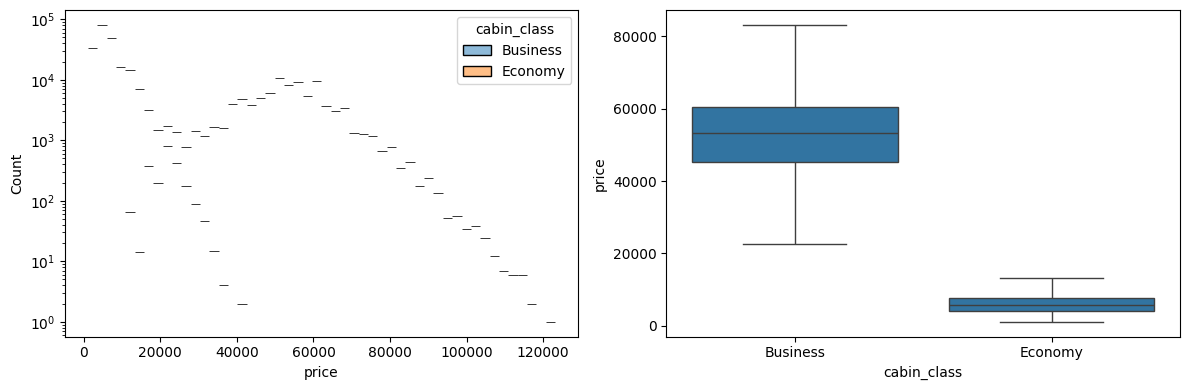

Conclusión: clase, aerolínea, ruta, escalas y duración presentan diferencias de precio relevantes.


In [8]:
# Actividad 7: se dividirán los datos en entrenamiento y prueba, y se prepararán los tres modelos candidatos.
import sys, re
import matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


FIG=Path('figures'); FIG.mkdir(exist_ok=True)

def clean_flights(df):
 d=df.copy(); d['price']=pd.to_numeric(d.price.astype(str).str.replace(',','',regex=False)); d['stop']=d.stop.map(normalized_stop)
 d['duration_minutes']=d.time_taken.map(duration_to_minutes)
 d['dep_minutes']=d.dep_time.map(lambda x:x.hour*60+x.minute); d['arr_minutes']=d.arr_time.map(lambda x:x.hour*60+x.minute)
 d['month']=d.date.dt.month; d['day']=d.date.dt.day; d['dayofweek']=d.date.dt.dayofweek; d['route']=d['from']+'_'+d['to']
 return d.drop_duplicates().reset_index(drop=True)
flights=clean_flights(flights_raw)
print(flights.groupby('cabin_class').price.agg(['count','mean','median','min','max']).round(2))
fig,ax=plt.subplots(1,2,figsize=(12,4)); sns.histplot(flights,x='price',hue='cabin_class',bins=50,log_scale=(False,True),ax=ax[0]); sns.boxplot(flights,x='cabin_class',y='price',showfliers=False,ax=ax[1]); plt.tight_layout(); plt.savefig(FIG/'eda_price.png',dpi=120); plt.show()
print('Conclusión: clase, aerolínea, ruta, escalas y duración presentan diferencias de precio relevantes.')

## 8. Elige una grilla de hiperparametros y luego optimízalos, buscando la mejor combinación para cada grilla. Guardar los modelos entrenados.

price               1.00
duration_minutes    0.32
arr_minutes         0.09
dayofweek           0.03
dep_minutes         0.01
day                -0.01
month              -0.28
Name: price, dtype: float64


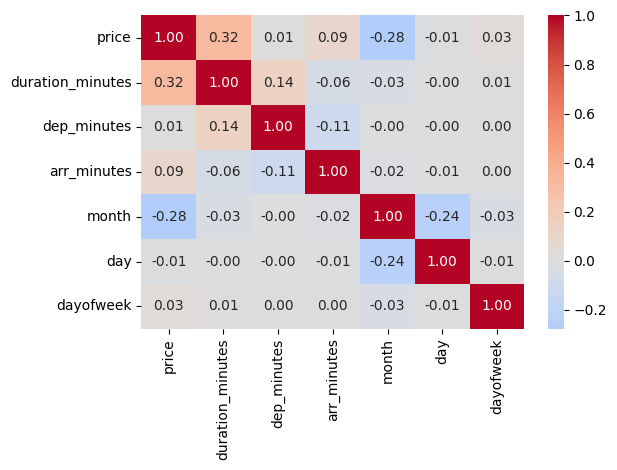

Se retienen categorías (clase, aerolínea, ruta y escalas): sus efectos no lineales se capturarán con los modelos.


In [9]:
# Actividad 8: se optimizarán hiperparámetros con validación cruzada y se guardarán los mejores modelos entrenados.
num=['price','duration_minutes','dep_minutes','arr_minutes','month','day','dayofweek']
corr=flights[num].corr(method='spearman')
print(corr.price.sort_values(ascending=False))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0); plt.tight_layout(); plt.savefig(FIG/'correlations.png',dpi=120); plt.show()
print('Se retienen categorías (clase, aerolínea, ruta y escalas): sus efectos no lineales se capturarán con los modelos.')

## 9. Define al menos 3 métricas para evaluar los modelos entrenados y genera gráficos de comparación. Elige un baseline para ver qué tan buena es tu opción respecto a ese baseline y concluye.

In [10]:
# Actividad 9: se evaluarán los modelos y el baseline con MAE, RMSE y R²; luego se compararán gráficamente.
numeric_features=['duration_minutes','dep_minutes','arr_minutes','month','day','dayofweek']
categorical_features=['airline','from','to','route','stop','cabin_class']
features=numeric_features+categorical_features
X,y=flights[features],flights.price
print('Variables:',features); print('Matriz:',X.shape,'| nulos:',X.isna().sum().sum())

Variables: ['duration_minutes', 'dep_minutes', 'arr_minutes', 'month', 'day', 'dayofweek', 'airline', 'from', 'to', 'route', 'stop', 'cabin_class']
Matriz: (300259, 12) | nulos: 0


## 10. Genera una conclusión final respecto a qué tan útiles son los resultados encontrados para resolver el problema propuesto y define cuáles podrían ser los próximos pasos para el proyecto

In [11]:
# Actividad 10: se resumirán los resultados del mejor modelo y se propondrán próximos pasos para el proyecto.
def prepare_features(raw):
 d=clean_flights(raw)
 return d[features].copy(),d.price.copy()
X_check,y_check=prepare_features(flights_raw)
print('Función validada:',X_check.shape,y_check.shape)

Función validada: (300259, 12) (300259,)


In [12]:
# Se ejecutará este bloque para completar y validar la actividad correspondiente.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42,stratify=flights.cabin_class)
linear=ColumnTransformer([('num',StandardScaler(),numeric_features),('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)])
tree=ColumnTransformer([('num','passthrough',numeric_features),('cat',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1),categorical_features)])
models={'Ridge':Pipeline([('prep',linear),('model',Ridge())]),'Random Forest':Pipeline([('prep',tree),('model',RandomForestRegressor(random_state=42,n_jobs=-1))]),'HistGradientBoosting':Pipeline([('prep',tree),('model',HistGradientBoostingRegressor(random_state=42))])}
print('Train:',X_train.shape,'Test:',X_test.shape,'| candidatos:',list(models))

Train: (240207, 12) Test: (60052, 12) | candidatos: ['Ridge', 'Random Forest', 'HistGradientBoosting']


In [13]:
# Se ejecutará este bloque para completar y validar la actividad correspondiente.
MODEL=Path('models'); MODEL.mkdir(exist_ok=True)
idx,_=train_test_split(np.arange(len(X_train)),train_size=50000,random_state=42,stratify=X_train.cabin_class)
grids={'Ridge':{'model__alpha':[1,10]},'Random Forest':{'model__n_estimators':[60],'model__max_depth':[16,24],'model__min_samples_leaf':[2]},'HistGradientBoosting':{'model__learning_rate':[.06,.1],'model__max_leaf_nodes':[31,63]}}
best={}; tune=[]
for name,model in models.items():
 s=GridSearchCV(model,grids[name],cv=2,scoring='neg_mean_absolute_error',n_jobs=-1)
 s.fit(X_train.iloc[idx],y_train.iloc[idx]); best[name]=s.best_estimator_.fit(X_train,y_train)
 joblib.dump(best[name],MODEL/(name.replace(' ','_')+'.joblib')); tune.append([name,-s.best_score_,s.best_params_])
print(pd.DataFrame(tune,columns=['modelo','MAE CV','mejores parámetros']).to_string(index=False))

              modelo   MAE CV                                                                mejores parámetros
               Ridge 4,488.79                                                              {'model__alpha': 10}
       Random Forest 1,677.30 {'model__max_depth': 24, 'model__min_samples_leaf': 2, 'model__n_estimators': 60}
HistGradientBoosting 1,980.84                        {'model__learning_rate': 0.1, 'model__max_leaf_nodes': 63}


              modelo       MAE      RMSE    R2
       Random Forest    946.39  2,326.83  0.99
HistGradientBoosting  1,828.88  3,070.60  0.98
               Ridge  4,535.73  6,738.24  0.91
            Baseline 16,149.55 26,415.62 -0.35


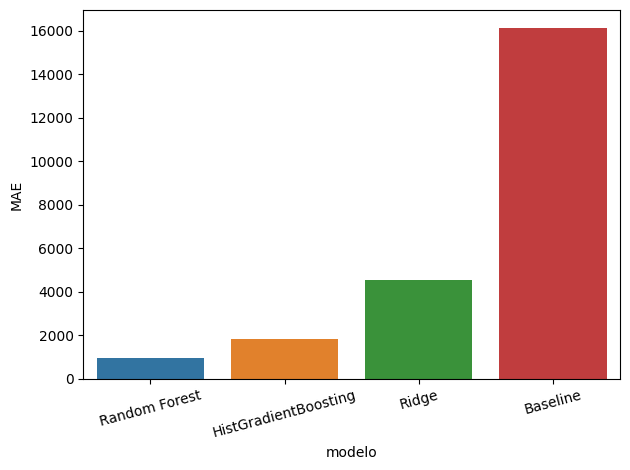

Menor MAE y RMSE, y mayor R² indican mejor desempeño; el baseline permite medir la ganancia real.


In [14]:
# Se ejecutará este bloque para completar y validar la actividad correspondiente.
def score(name,m):
 p=m.predict(X_test); return [name,mean_absolute_error(y_test,p),mean_squared_error(y_test,p)**.5,r2_score(y_test,p)]
baseline=DummyRegressor(strategy='median').fit(X_train,y_train)
results=pd.DataFrame([score('Baseline',baseline)]+[score(n,m) for n,m in best.items()],columns=['modelo','MAE','RMSE','R2']).sort_values('MAE')
print(results.round(2).to_string(index=False))
sns.barplot(results,x='modelo',y='MAE',hue='modelo',legend=False); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig(FIG/'model_comparison.png',dpi=120); plt.show()
print('Menor MAE y RMSE, y mayor R² indican mejor desempeño; el baseline permite medir la ganancia real.')

In [15]:
# Se ejecutará este bloque para completar y validar la actividad correspondiente.
winner=results.iloc[0]
print(f"Mejor modelo: {winner.modelo}; MAE={winner.MAE:,.2f}; RMSE={winner.RMSE:,.2f}; R²={winner.R2:.3f}")
print('El modelo es útil para cotizaciones iniciales. Próximos pasos: incluir anticipación de compra, disponibilidad, demanda y validación temporal; monitorear el error por ruta y clase.')

Mejor modelo: Random Forest; MAE=946.39; RMSE=2,326.83; R²=0.990
El modelo es útil para cotizaciones iniciales. Próximos pasos: incluir anticipación de compra, disponibilidad, demanda y validación temporal; monitorear el error por ruta y clase.
